In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [15]:
df = pd.read_csv("NetFlix.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [16]:
df.shape

(7787, 12)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [18]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787.000000,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,NaN,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,NaN,TV-MA,NaN,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,NaN,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,69.122769,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,50.950743,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,88.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,106.000000,NaN,NaN


In [19]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [20]:
df.duplicated().sum()

0

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [23]:
df["director"] = df["director"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

In [24]:
df["date_added"] = pd.to_datetime(df["date_added"])

C:\Users\admin\AppData\Local\Temp\ipykernel_10216\2066754708.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_added"] = pd.to_datetime(df["date_added"])


In [25]:
df['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

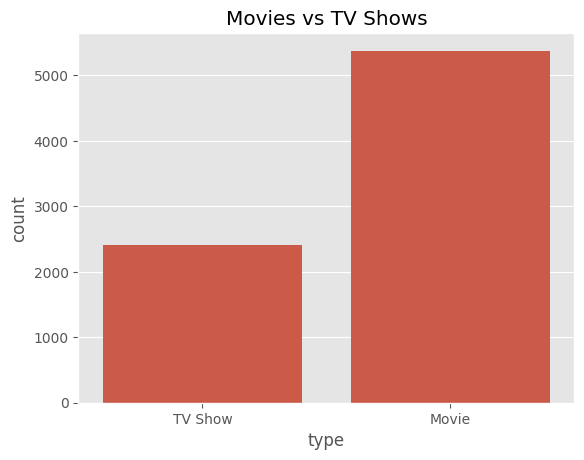

In [26]:
sns.countplot(data=df,x='type')

plt.title("Movies vs TV Shows")
plt.show()

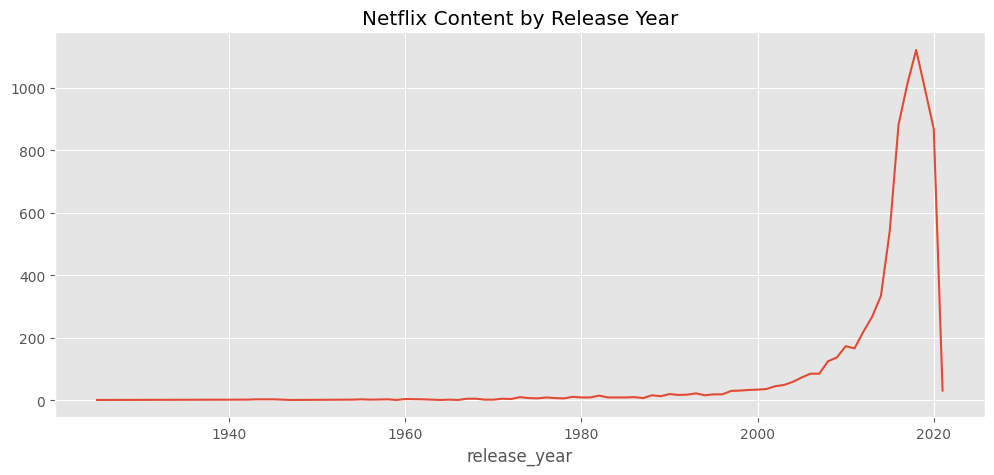

In [28]:
year=df['release_year'].value_counts().sort_index()

year.plot(figsize=(12,5))

plt.title("Netflix Content by Release Year")

plt.show()

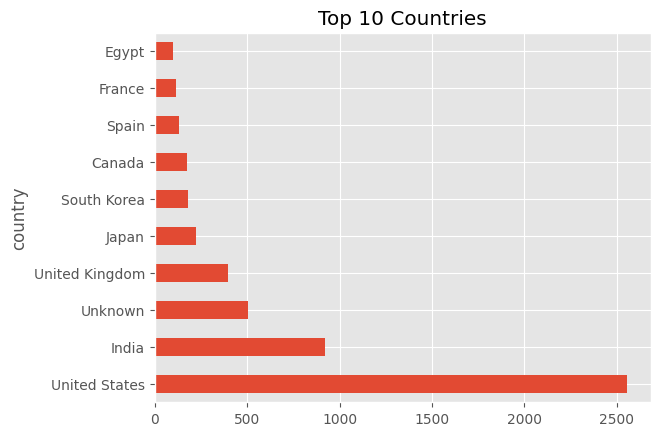

In [30]:
country=df['country'].value_counts().head(10)

country.plot(kind='barh')

plt.title("Top 10 Countries")

plt.show()

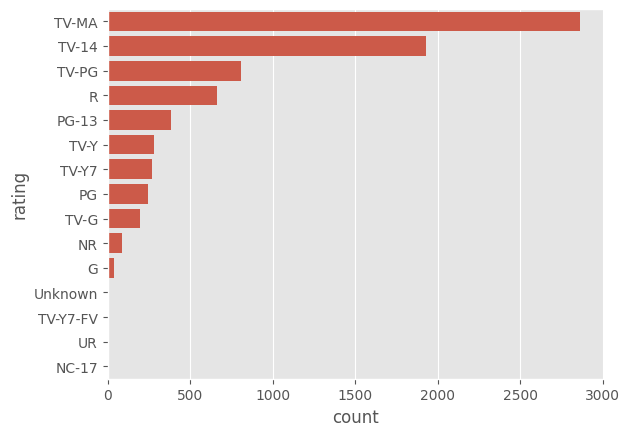

In [32]:
sns.countplot(y='rating',data=df,order=df['rating'].value_counts().index)

plt.show()


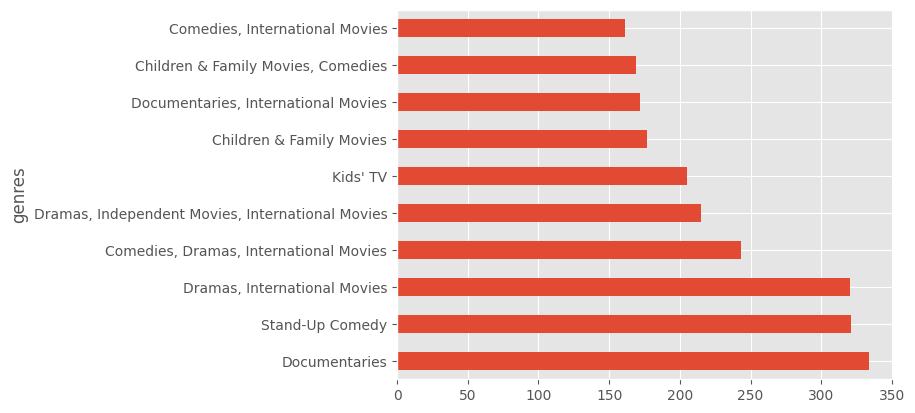

In [34]:
genre=df['genres'].value_counts().head(10)

genre.plot(kind='barh')

plt.show()

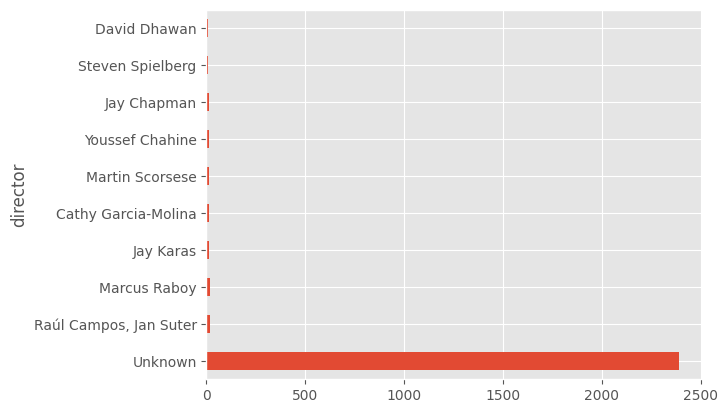

In [36]:
director=df['director'].value_counts().head(10)

director.plot(kind='barh')

plt.show()

In [38]:
movies=df[df['type']=='Movie']

In [50]:
df['duration'].head(10)

0      4
1    143
2    124
3     90
4      1
5     90
6     94
7    112
8    129
9     85
Name: duration, dtype: int64

<Figure size 800x500 with 0 Axes>

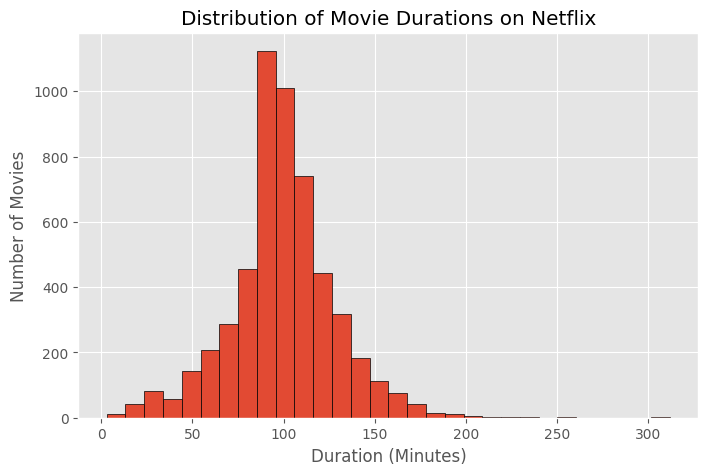

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(movies['duration'], bins=30, edgecolor='black')

plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Durations on Netflix")

plt.show()

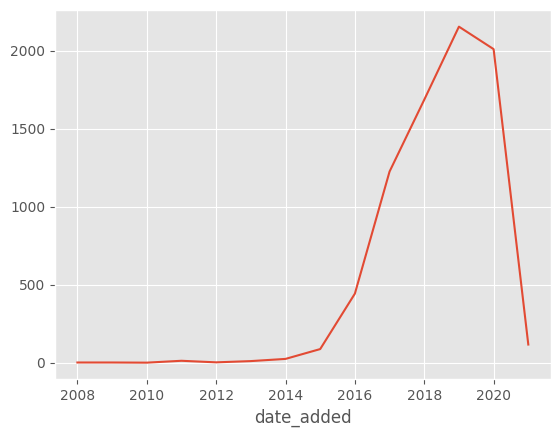

In [60]:
added=df['date_added'].dt.year.value_counts().sort_index()

added.plot()

plt.show()

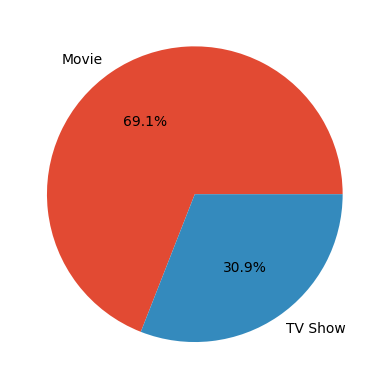

In [62]:
df['type'].value_counts().plot(
kind='pie',
autopct='%1.1f%%')

plt.ylabel("")

plt.show()

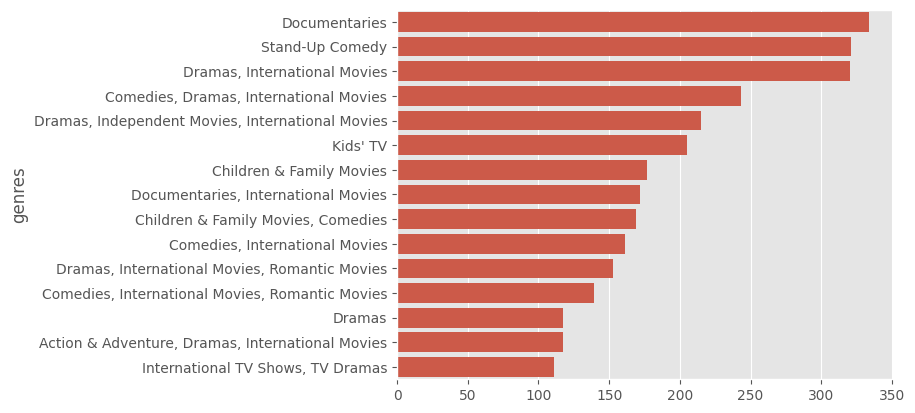

In [64]:
top=df['genres'].value_counts().head(15)

sns.barplot(
x=top.values,
y=top.index)

plt.show()